Размерность векторов K = 25
Число эталонов L = 3

--- Проверка эталонов ---
Образ N успешно восстановлен (неподвижная точка).
Образ O успешно восстановлен (неподвижная точка).
Образ P успешно восстановлен (неподвижная точка).

--- Тестирование с 10% шума ---
Буква N: исходный -> зашумлённый (10%) -> восстановлен за 2 итераций.


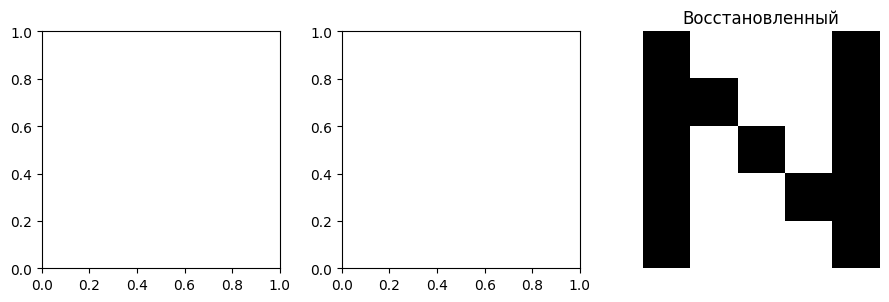

Буква O: исходный -> зашумлённый (10%) -> восстановлен за 2 итераций.


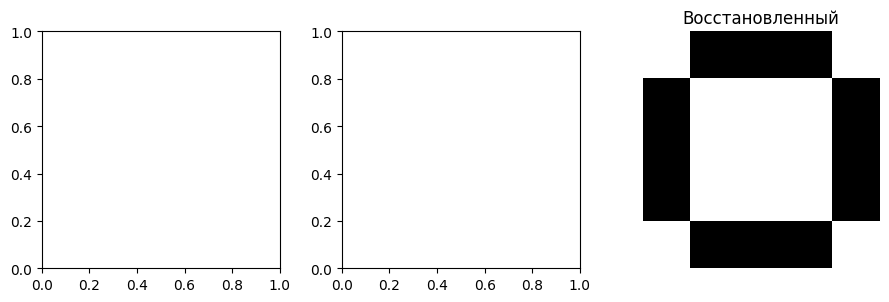

Буква P: исходный -> зашумлённый (10%) -> восстановлен за 2 итераций.


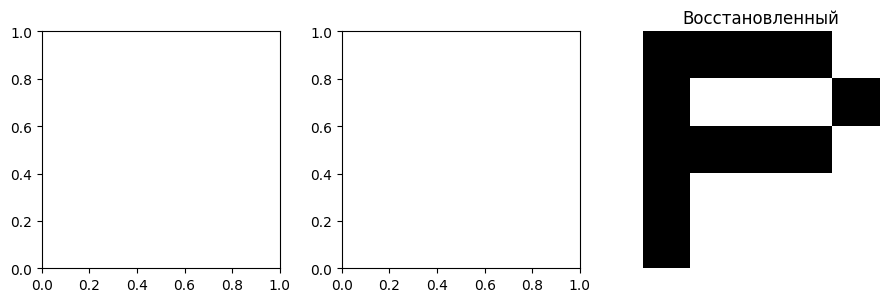

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#  Эталонные образы (5x5, биполярные)
def pattern_N():
    return np.array([[ 1, -1, -1, -1,  1],
                     [ 1,  1, -1, -1,  1],
                     [ 1, -1,  1, -1,  1],
                     [ 1, -1, -1,  1,  1],
                     [ 1, -1, -1, -1,  1]])

def pattern_O():
    return np.array([[-1,  1,  1,  1, -1],
                     [ 1, -1, -1, -1,  1],
                     [ 1, -1, -1, -1,  1],
                     [ 1, -1, -1, -1,  1],
                     [-1,  1,  1,  1, -1]])

def pattern_P():
    return np.array([[ 1,  1,  1,  1, -1],
                     [ 1, -1, -1, -1,  1],
                     [ 1,  1,  1,  1, -1],
                     [ 1, -1, -1, -1, -1],
                     [ 1, -1, -1, -1, -1]])

# Векторизация
patterns = [pattern_N().flatten(), pattern_O().flatten(), pattern_P().flatten()]
K = len(patterns[0])
L = len(patterns)
print(f"Размерность векторов K = {K}")
print(f"Число эталонов L = {L}")

# Обучение (веса по Хеббу)
W = np.zeros((K, K))
for i in range(K):
    for j in range(K):
        if i != j:
            s = 0
            for l in range(L):
                s += patterns[l][i] * patterns[l][j]
            W[i, j] = s
        else:
            W[i, j] = 0

# Асинхронное функционирование
def hopfield_asynch(x, W, max_iter=100, random_order=True):
    y = x.copy()
    history = [y.copy()]
    for _ in range(max_iter):
        order = np.random.permutation(K) if random_order else range(K)
        for k in order:
            net = np.dot(W[:, k], y)   # W[:,k] - веса, входящие в нейрон k
            # (диагональный элемент W[k,k]=0, поэтому self-связь не учитывается)
            if net > 0:
                y[k] = 1
            elif net < 0:
                y[k] = -1
            # при net == 0 значение не меняется
        if np.array_equal(history[-1], y):
            break
        history.append(y.copy())
    return y, history

#  Тестирование на эталонах
print("\n--- Проверка эталонов ---")
for idx, p in enumerate(patterns):
    recalled, _ = hopfield_asynch(p, W)
    if np.array_equal(recalled, p):
        print(f"Образ {['N','O','P'][idx]} успешно восстановлен (неподвижная точка).")
    else:
        print(f"Образ {['N','O','P'][idx]} НЕ является устойчивым!")

#  Искажение 10% битов
def add_noise(pattern, noise_percent=0.1):
    noisy = pattern.copy()
    num_flip = int(K * noise_percent)
    flip_indices = np.random.choice(K, num_flip, replace=False)
    noisy[flip_indices] *= -1
    return noisy

def show_pattern(vec, title=""):
    plt.imshow(vec.reshape(5,5), cmap='gray_r', vmin=-1, vmax=1)
    plt.title(title)
    plt.axis('off')

print("\n--- Тестирование с 10% шума ---")
for idx, p in enumerate(patterns):
    noisy = add_noise(p, 0.1)
    recalled, hist = hopfield_asynch(noisy, W)
    print(f"Буква {['N','O','P'][idx]}: исходный -> зашумлённый (10%) -> восстановлен за {len(hist)} итераций.")
    # Визуализация
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    show_pattern(p, f"Эталон {['N','O','P'][idx]}")
    show_pattern(noisy, f"Зашумлённый (10%)")
    show_pattern(recalled, f"Восстановленный")
    plt.tight_layout()
    plt.show()